In [2]:
# Example loading and plotting lidar data of Hybrid Dune Campaign

import numpy as np
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import colorcet as cc   # For color maps

import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from netCDF4 import Dataset
import sys
sys.path.append('./functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


In [1]:
1+2

3

In [3]:
# define functions
def sph2cart(azimuth,elevation,r):
    rcoselev = r * np.cos(elevation)
    x = rcoselev * np.cos(azimuth)
    y = rcoselev * np.sin(azimuth)
    z = r * np.sin(elevation)
    return x, y, z

def rad2deg(angleInRadians):
    angleInDegrees = 180/np.pi * angleInRadians
    return angleInDegrees

def deg2rad(angleInDegrees):
    angleInRadians = np.pi/180 * angleInDegrees
    return angleInRadians

In [4]:
def filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=None, profile_isel=None):
    # Example loading and filtering lidar data of Hybrid Dune Campaign

    # Define frame angles to be skipped
    # Initialize the array: shape (3, 2, 4, 3)
    hoek_frame_skip = np.zeros((3, 2, 4, 3))
    # S1
    hoek_frame_skip[:, :, 0, 0] = [[-17.4, -14.9], [-13.8, -10.9], [-2.75, 0]]   # storm 1
    hoek_frame_skip[:, :, 0, 1] = [[-16.9, -13.9], [-13.3, -9.9], [-2.25, 0.5]]  # storm 2
    hoek_frame_skip[:, :, 0, 2] = [[-17.4, -14.4], [-13.8, -10.9], [-2.75, 0]]   # storm 3

    # S2
    hoek_frame_skip[:, :, 1, 0] = [[-21.2, -18.2], [-14.3, -11.3], [-2.3, 0.7]]
    hoek_frame_skip[:, :, 1, 1] = [[-20.2, -17.7], [-13.8, -10.8], [-1.3, 1.7]]
    hoek_frame_skip[:, :, 1, 2] = [[-21.2, -18.2], [-14.3, -11.8], [-2.3, 0.7]]

    # S3
    hoek_frame_skip[:, :, 2, 0] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 1] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 2] = [[-17.5, -14.5], [-12.5, -10.0], [0.5, 4.0]]

    # S4
    hoek_frame_skip[:, :, 3, 0] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 1] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 2] = [[-19.75, -16.75], [-11.75, -8.75], [-3.25, -0.25]]

    # # determine limits to load data from: which vertical angles to select. Between -90° and 105°
    # ds = xr.open_dataset(nc_in).isel(profile_number=0, t=0, echos=0)   # select specific time range: t0 until t_end

    # # # find obs_number with -90° < beam_angle < 105°
    # i_obs_start = np.where(ds.beam_angle.values > -90)[0][0]
    # i_obs_end = np.where(ds.beam_angle.values < 93)[0][-1]
    # print(i_obs_end)

    i_obs_start = 360  # set manually, always the same if looking for the same angles.Here: straight under lidar
    i_obs_end = 545 # for 93deg

    # load data with these obs_number limits
    if (t_sel is  None) and (profile_isel is None):
        ds = xr.open_dataset(nc_in).isel(obs_number=slice(i_obs_start, i_obs_end))                                            # select specific angles
    elif t_sel is None:
        ds = xr.open_dataset(nc_in).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))               # select specific angles and profile
    elif profile_isel is None:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(obs_number=slice(i_obs_start, i_obs_end))                               # select specific angles and time range
    else:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))  # select specific angles, profile and time range

    # Filter out the frame -----------------------------------------------------------------------
    # Filter out the frame by replacing values in ds.beam_angle with NaN where the laser sees the frame. Then use filtered beam angles for coordianate conversion.

    # Select the slice for given n_lidar and n_storm (Python: 0-based)
    # Example: n_lidar = 1, n_storm = 2 (MATLAB) -> Python: 0, 1
    hoek_frame_skip_slice = hoek_frame_skip[:, :, n_lidar-1, n_storm-1] 

    # Filter frame: loop, for every row in hoek_frame_skip_slice, make angles nan where angles>value_col_1 and angles<value_col_2
    angles = ds.beam_angle.values

    for row in hoek_frame_skip_slice:
        angles[(angles > row[0]) & (angles < row[1])] = np.nan

    ds.beam_angle.values = angles   

    # Convert to local coordinates
    ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=False, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

    # Define skip area (to remove points below x=6m and above z=-1m)
    x_skip_area = 6.5   # delete every point that is less than 6 m landward of lidar, and (simultaneously) less than 1 m below the lidar
    z_skip_area = -1
    x_min = ds.x_i_local.values + x_skip_area
    z_max = ds.z_i.values + z_skip_area

    # make x, y, z values nan where (x < x_skip_area) & (z > z_skip_area)
    mask_keep = (ds.x.values > x_min) | (ds.z.values < z_max) # keep where either condition is met. So remove where <x_lmin and >z_max
    ds['x'] = ds.x.where(mask_keep)
    #ds['y'] = ds.y.where(mask_keep)
    ds['z'] = ds.z.where(mask_keep)
    ds['radius_lidar'] = ds.radius_lidar.where(mask_keep)

    return ds


In [6]:
# LOAD AND TRANSFORM LIDAR DATA FILE 1 (TOPVIEW, SIDEVIEW POINTCLOUD)
nc_in = r"O:\HybridDune experiment\data lidar netcdf\10s interval\storm1_lidar1_polar_10sinterval - new.nc"
t_select = [pd.Timestamp('2024-12-18 14:10'), pd.Timestamp('2024-12-19 18:01')]
ds = xr.open_dataset(nc_in).sel(t=t_select)                                                           # select specific timesteps (here first pointcloud, plus pointcould at storm

# Extract variables from dataset -----------------------------------------------------------------------
profile_angle      = ds.profile_angle
beam_angle         = ds.beam_angle
r                  = ds.radius_lidar # Dimensions if full netcdf is loaded in dataset: 3 echos x 16 profiles x 720 obs x T timesteps
#I                  = ds.intensity #uncommend when used
rotation_matrix    = ds.rotation_matrix_lidar_to_RD.values  # shape: (3, 3)
translation_matrix = np.array([ds.x_i_RD.values, ds.y_i_RD.values, ds.z_i.values])  # shape: (3,)

# Convert polar coordinates to cartesian coordinates, in local lidar coord system -----------------------------------------------------------------------
[x_lidar,y_lidar,z_lidar] = sph2cart( deg2rad(beam_angle), deg2rad(profile_angle), r ) # convert to xyz coordinates, in m. Axes origin at lidar, physical direction of axes depends on lidar placement

# Convert to RD system -----------------------------------------------------------------------
# Stack lidar coordinates into shape (..., 3) for matrix multiplication
xyz_lidar = np.stack([x_lidar, y_lidar, z_lidar], axis=-1)  # stack in next dimension. if r is 4D, then xyz_lidar is 5D, with last dimension size 3

# Apply rotation (matrix multiply last axis) and translation
xyz_RD = np.matmul(xyz_lidar, rotation_matrix) + translation_matrix  

# Transform to x,y coordinates in local coordinate system (alongshore, cross shore) ------------------------------
theta = np.deg2rad(36.0) # local grid is rotated 36 degrees clockwise wrt RD system
rotation_matrix_RDtoLocal = np.array([ [np.cos(theta), np.sin(theta), 0],[-np.sin(theta), np.cos(theta), 0], [0, 0, 1] ])

# Subtract zero-point of local grid, then rotate 36 degrees
xyz_local = xyz_RD - np.array([71683.584, 452356.055, 0])  # shape: (3,)
xyz_local = np.matmul(xyz_local, rotation_matrix_RDtoLocal)  # shape: (16, 720, 10, 3)

# Separate x,y,z components: take the 1st/2nd/3rd slice of last dimension ----------------------------------------------------------------
x = xyz_local[..., 0]  #  dims: echos x profiles x obs x timesteps
y = xyz_local[..., 1]  
z = xyz_local[..., 2]   


In [7]:
# Load file with detailed data (4 hz) FOR WAVE, transform coordinates

# Define file, check file contents
nc_in = r"O:\HybridDune experiment\data lidar netcdf\S1 Lidar, storm1.nc"

t_start = pd.Timestamp('2024-12-19 18:00')
t_end = pd.Timestamp('2024-12-19 18:10')
ds = xr.open_dataset(nc_in).sel(t=slice(t_start, t_end), profile_number=2)                                              # select specific time range

# Extract variables from dataset -----------------------------------------------------------------------
profile_angle      = ds.profile_angle
beam_angle         = ds.beam_angle
r                  = ds.radius_lidar # Dimensions if full netcdf is loaded in dataset: 3 echos x 16 profiles x 720 obs x T timesteps
#I                  = ds.intensity #uncommend when used
rotation_matrix    = ds.rotation_matrix_lidar_to_RD.values  # shape: (3, 3)
translation_matrix = np.array([ds.x_i_RD.values, ds.y_i_RD.values, ds.z_i.values])  # shape: (3,)

# NB: Along the echos axis, points are sorted by distance. If there are multiple echos, the first value is closest to the lidar, the last non-NaN value is the farthest away. 
# When interested in .e.g. bed levels: to get a single r and I value per direction, it makes sense to take the furthest point (most likely to be bed instead of water). 
# The code below does this for radius r and intensity I. 

# # Find last non-NaN along the first axis (echos)
r = r.isel(echos=slice(None, None, -1))  # flip along 'echos'
#I = I.isel(echos=slice(None, None, -1))  # flip along 'echos'

mask = ~np.isnan(r)
idx = mask.argmax(dim='echos')

r = r.isel(echos=idx)
#I = I.isel(echos=idx)

# Convert polar coordinates to cartesian coordinates, in local lidar coord system -----------------------------------------------------------------------
[x_lidar,y_lidar,z_lidar] = sph2cart( deg2rad(beam_angle), deg2rad(profile_angle), r ) # convert to cartesian xyz coordinates, in m
# Axes origin at lidar. Physical direction of the axes depends on how the lidar is placed on the beach. Transformed to RD coordinates below

# Convert to RD system -----------------------------------------------------------------------
# Stack lidar coordinates into shape (..., 3) for matrix multiplication
xyz_lidar = np.stack([x_lidar, y_lidar, z_lidar], axis=-1)  # stack in next dimension. if r is 4D, then xyz_lidar is 5D, with last dimension size 3

# Apply rotation (matrix multiply last axis) and translation
xyz_RD = np.matmul(xyz_lidar, rotation_matrix) + translation_matrix  

# Transform to x,y coordinates in local coordinate system (alongshore, cross shore) ------------------------------
theta = np.deg2rad(36.0) # local grid is rotated 36 degrees clockwise wrt RD system
rotation_matrix_RDtoLocal = np.array([ [np.cos(theta), np.sin(theta), 0],[-np.sin(theta), np.cos(theta), 0], [0, 0, 1] ])

# Subtract zero-point of local grid, then rotate 36 degrees
xyz_local = xyz_RD - np.array([71683.584, 452356.055, 0])  # shape: (3,)
xyz_local = np.matmul(xyz_local, rotation_matrix_RDtoLocal)  # shape: (16, 720, 10, 3)

# Separate x,y,z components: take the 1st/2nd/3rd slice of last dimension ----------------------------------------------------------------
x2 = xyz_local[..., 0]  #  dims: echos x profiles x obs x timesteps
y2 = xyz_local[..., 1]  
z2 = xyz_local[..., 2]   

In [5]:
# lOAD POINTCLOUD FOR DUNE PROFILES AND FILTER DATA
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 1  # set as needed (1-based, like MATLAB)

for n_storm in [1]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"O:\HybridDune experiment\data lidar netcdf\s{n_lidar} Lidar, storm{n_storm}.nc"
    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 00:00') # was 2:00
        t2 = pd.Timestamp('20-12-2024 00:09') # was 19dec 22:00
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:09')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    #ds.close()
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)
    ds = ds.drop_vars(['x','z'])

    # EXTRACT DUNE PROFILES FROM POINTCLOUDS ----------------------------------------------------------------------------
    # take moving max radius over X minutes, ignore NaNs
    dt_minutes = 10
    window_length = np.int16(dt_minutes * 60 * ds.sf.values) # 5 minutes * 60 seconds * 4 Hz
    ds['radius_lidar'] = ds.radius_lidar.rolling(t=window_length, center=True, min_periods=1).max()   # min_periods=1: 1 non-nan value is enough. So A) ignore nans and b) ignore window edges

    # Select one point cloud per window: For each instant in time_vector, select the first t >= time_vector[i]
    #time_vector = pd.date_range(start=t1, end=t2, freq=f'{dt_minutes}min')
    time_vector = pd.date_range(start=t1, end=t2, freq='20min')

    t_vals = pd.to_datetime(ds.t.values)
    selected_indices = []
    for t_ref in time_vector:
        idx = np.searchsorted(t_vals, t_ref, side='left')
        if idx < len(t_vals):
            selected_indices.append(idx)

    ds_plot = ds.isel(t=selected_indices)

    # Remove outliers: make r nan where the difference between consecutive r values over dim obs_number is larger than 0.5 m
    mask_full = xr.DataArray(np.ones_like(ds_plot.radius_lidar, dtype=bool), dims=ds_plot.radius_lidar.dims, coords=ds_plot.radius_lidar.coords)  # pre-define mask: size of ds.radius_lidar, true everywhere
    r_diff = ds_plot.radius_lidar.diff(dim='obs_number')                     # Calculate the difference between consecutive values
    mask = np.abs(r_diff) <= 0.5                                        # Create a mask: True where the difference is <= 0.5, False where it's an outlier
    mask_full.values[1:,:] = mask.values                                # Combine the mask
    ds_plot['radius_lidar'] = ds_plot.radius_lidar.where(mask_full)               # Apply the mask: set outliers to NaN

    # Recalculate x and z, based on the max r per window
    ds_plot = convert_lidar_coordinates_ds(ds_plot, 'local', max_echos=False, keep_I=False, keep_r=False, keep_y=False) # skip intensity, take max distance of echos

    

    if n_storm == 1:
        ds1a=ds_plot.copy()
    elif n_storm == 2:
        ds2a=ds_plot.copy()
    elif n_storm == 3:
        ds3a=ds_plot.copy()

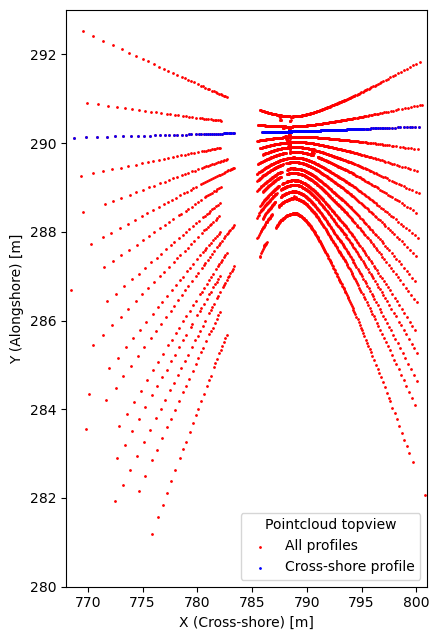

In [47]:
# Plot profiles
x_plot = np.squeeze(x[:,:,:,0])   # dims: echos x profiles x obs x timesteps.  So select first timestep
x_plot2 = np.squeeze(x[:,2,:,0])  # additionally select profile 2 (starting count at 0), i.e. cross-shore profile
y_plot = np.squeeze(y[:,:,:,0])
y_plot2 = np.squeeze(y[:,2,:,0])
z_plot = np.squeeze(z[:,2,:,0])

# plot x vs y and x vs z in two subplots. 
fig, axs = plt.subplots(1, 1, figsize=(4.5,6.5))
axs.scatter(x_plot, y_plot, c='r', s=1, label='All profiles')
axs.scatter(x_plot2, y_plot2, c='b', s=1, label='Cross-shore profile')
axs.legend(title='Pointcloud topview')

axs.set_xlim(768,801)
axs.set_ylim(280,293)

axs.set_xlabel('X (Cross-shore) [m]')
axs.set_ylabel('Y (Alongshore) [m]')
#axs.set_title('Topview of pointcloud at S1 Dike-in-dune')

plt.tight_layout()
fig.savefig('Plot Lidars S1 topview.svg', bbox_inches='tight')           # PDF

plt.show()

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_17952\1154752414.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


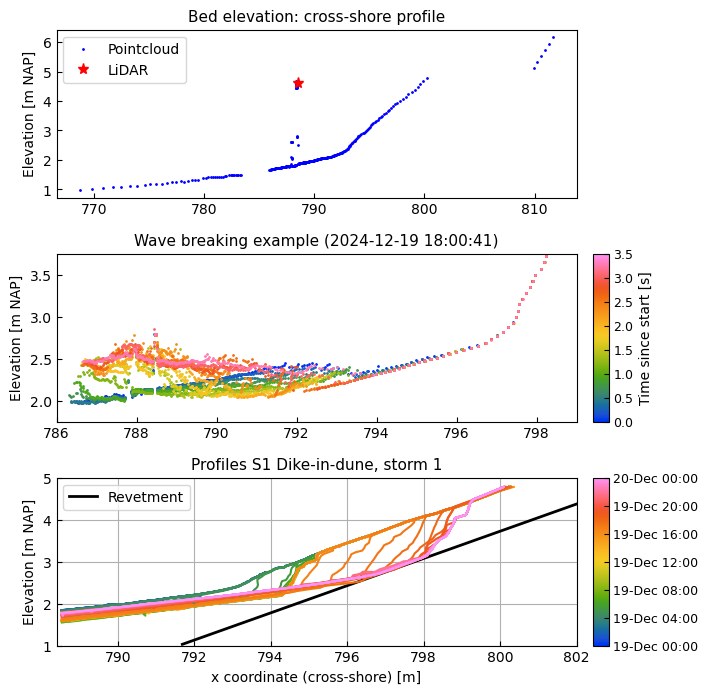

In [17]:
# Plot profiles
x_plot = np.squeeze(x[:,:,:,0])   # dims: echos x profiles x obs x timesteps.  So select first timestep
x_plot2 = np.squeeze(x[:,2,:,0])  # additionally select profile 2 (starting count at 0), i.e. cross-shore profile
y_plot = np.squeeze(y[:,:,:,0])
y_plot2 = np.squeeze(y[:,2,:,0])
z_plot = np.squeeze(z[:,2,:,0])

# plot x vs y and x vs z in two subplots. 
fig = plt.figure(figsize=(8, 8))

# Create 3 subplots: profiles and waterlevels, manually controlling axes positions for perfect alignment
# Define left, width, and heights for both axes (excluding colorbar)
left = 0.1
width = 0.65
height1 = 0.21
height2 = 0.21
height3 = 0.21
bottom1 = 0.64
bottom2 = 0.36
bottom3 = 0.08

ax1 = fig.add_axes([left, bottom1, width, height1])
ax2 = fig.add_axes([left, bottom2, width, height2])
ax3 = fig.add_axes([left, bottom3, width, height3])

# Plot sideview -----------------------------------------------------------------------------
ax1.scatter(x_plot2, z_plot, c='b', s=1, label='Pointcloud')
ax1.plot(ds.x_i_local, ds.z_i, 'r*', markersize=8, label='LiDAR')  # plot lidar position
#ax1.set_xlabel('X (Cross-shore) [m]')
ax1.set_ylabel('Elevation [m NAP]')
ax1.set_title('Bed elevation: cross-shore profile',fontsize=11) # NB: no filtering applied. So points can be lidar frame, bed, waves, rain, ...
ax1.legend()

# Plot x, z as scatter. Plot wave with multiple timesteps. Let marker color indicate time -------------------------------------------------
cmap = plt.get_cmap('cet_CET_R1')

i_start = 165       # first timestep to plot                this selection gives some wave runup on the dune to
i_end = i_start+15  # last timestep to plot (exclusive)     15 steps of 0.25s, is 3.75s
i_step = 1          # step size

for t in range(i_start, min(i_end, x2.shape[1]), i_step):
    timestep = ds.t.values[t]
    ax2.scatter(x2[:, t], z2[:, t], s=1, c=[cmap((t-i_start)/(i_end-i_start))], label=f't={(t-i_start)/4} s')

ax2.set_xlim([786, 799])
ax2.set_ylim([1.75, 3.75])
#ax2.set_xlabel('X (Cross-shore) [m]')
ax2.set_ylabel('Elevation [m NAP]')
ax2.set_title(f'Wave breaking example (2024-12-19 18:00:41)',fontsize=11)
#ax2.legend(markerscale=5, fontsize='small', loc='upper left', ncol=3)

# Colorbar for time: add as a separate axis to the right of ax3, not affecting ax2
cbar_left = left + width + 0.02
cbar_width = 0.02
cbar_height = height2
cbar_bottom = bottom2
cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])

norm = plt.Normalize(0, 3.5)  # time in seconds
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
n_ticks = 8
tick_locs = np.linspace(0, 3.5, n_ticks)
tick_labels = [f'{t:.1f}' for t in tick_locs]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels,fontsize=9)
# Put all tick marks inside the colorbar
cbar.ax.tick_params(axis='both', direction='in', left=False, right=True)
cbar.set_label('Time since start [s]')

# Plot dune profiles ------------------------------------------------------------------------------
s_plot = ds1a

# Plot data
x_construction = np.array([803.11, 791.69])
z_construction = np.array([  4.77,   1.07])-0.04 # shift 4 cm, to put top instead of center of line at y

t_vals = pd.to_datetime(ds_plot.t.values)
norm = plt.Normalize(mdates.date2num(t_vals).min(), mdates.date2num(t_vals).max())
cmap = plt.get_cmap('cet_CET_R1')

ax3.plot(x_construction, z_construction, linestyle='-', color='black', linewidth=2, label='Revetment')
for i_t, t in enumerate(t_vals):
    color = cmap(norm(mdates.date2num(t)))
    ax3.plot(ds_plot.x[:, i_t], ds_plot.z[:, i_t], marker='o', markersize=0, linestyle='-', color=color)

# Colorbar for time: add as a separate axis to the right of ax3, not affecting ax2
cbar_left = left + width + 0.02
cbar_width = 0.02
cbar_height = height3
cbar_bottom = bottom3
cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
n_ticks = 7
tick_locs = np.linspace(mdates.date2num(t_vals).min(), mdates.date2num(t_vals).max(), n_ticks)
tick_labels = [mdates.num2date(t).strftime('%d-%b %H:%M') for t in tick_locs]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels, fontsize=9)
# Put all tick marks inside the colorbar
cbar.ax.tick_params(axis='both', direction='in', left=False, right=True)

# labels and limits for profile plot
ax3.set_xlabel('x coordinate (cross-shore) [m]')
ax3.set_ylabel('Elevation [m NAP]')
ax3.set_title('Profiles S1 Dike-in-dune, storm 1',fontsize=11)
ax3.grid()
ax3.set_xlim(788.4, 802)

ax3.set_ylim(1,5)
ax3.legend()
# Put all tick marks inside the box for both axes
for ax in [ax1, ax2, ax3]:
    ax.tick_params(axis='both', direction='in')

plt.tight_layout()
#fig.savefig('Plot Lidars S1 sideview, wave, dune profiles.pdf', bbox_inches='tight')           # PDF
fig.savefig('Plot Lidars S1 sideview, wave, dune profiles.svg', bbox_inches='tight')           # SVG

plt.show()

In [9]:
# print the font sizes used in the plot
ax=ax3
print("Title font size:", ax.title.get_fontsize())
print("X label font size:", ax.xaxis.label.get_fontsize())
print("Y label font size:", ax.yaxis.label.get_fontsize())

xticklabels = ax.get_xticklabels()
yticklabels = ax.get_yticklabels()
if xticklabels:
    print("X tick label font size:", xticklabels[0].get_fontsize())
if yticklabels:
    print("Y tick label font size:", yticklabels[0].get_fontsize())
legend = ax.get_legend()
if legend is not None:
    # Legend title font size
    if legend.get_title() is not None:
        print("Legend title font size:", legend.get_title().get_fontsize())
    # First legend item font size
    legend_texts = legend.get_texts()
    if legend_texts:
        print("First legend item font size:", legend_texts[0].get_fontsize())

Title font size: 12.0
X label font size: 10.0
Y label font size: 10.0
X tick label font size: 10.0
Y tick label font size: 10.0
Legend title font size: 10.0
First legend item font size: 10.0


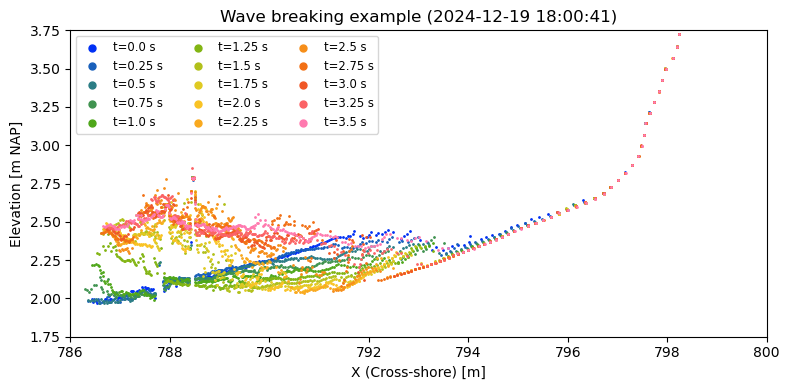

In [22]:
# Plot x, z as scatter. Plot multiple timesteps. Let marker color indicate time
fig = plt.figure(figsize=(8, 4))
cmap = plt.get_cmap('cet_CET_R1')

i_start = 165       # first timestep to plot                this selection gives some wave runup on the dune to
i_end = i_start+15  # last timestep to plot (exclusive)     15 steps of 0.25s, is 3.75s
i_step = 1          # step size

for t in range(i_start, min(i_end, x.shape[1]), i_step):
    timestep = ds.t.values[t]
    plt.scatter(x[:, t], z[:, t], s=1, c=[cmap((t-i_start)/(i_end-i_start))], label=f't={(t-i_start)/4} s')

plt.xlim([786, 800])
plt.ylim([1.75, 3.75])
plt.xlabel('X (Cross-shore) [m]')
plt.ylabel('Elevation [m NAP]')
plt.title(f'Wave breaking example (2024-12-19 18:00:41)')
plt.legend(markerscale=5, fontsize='small', loc='upper left', ncol=3)
plt.tight_layout()
plt.show()

(0.0, 4.0)

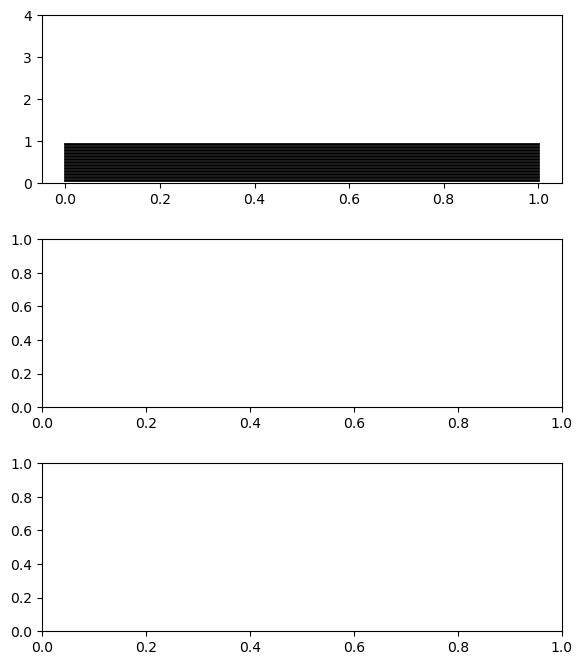

In [56]:
# Check width lines
fig = plt.figure(figsize=(8, 8))

# Create 3 subplots: profiles and waterlevels, manually controlling axes positions for perfect alignment
# Define left, width, and heights for both axes (excluding colorbar)
left = 0.1
width = 0.65
height1 = 0.21
height2 = 0.21
height3 = 0.21
bottom1 = 0.64
bottom2 = 0.36
bottom3 = 0.08

ax1 = fig.add_axes([left, bottom1, width, height1])
ax2 = fig.add_axes([left, bottom2, width, height2])
ax3 = fig.add_axes([left, bottom3, width, height3])

n=14
for i in range(1,n):
    ax1.plot([0,1],[i/n, i/n],linewidth=2,color='black')
ax1.set_ylim(0,4)

In [ ]:
a